In [ ]:
!pip install wordcloud

Uploaded files:
['.config', 'shreenithy_task2_model_comparison.csv', 'shreenithy_task2_predictions.csv', 'shreenithy_spam_sms_model.pkl', 'shreenithy_spam_tfidf_vectorizer.pkl', 'spam.csv', 'sample_data']

Dataset loaded successfully!
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Original Columns:
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

Final Dataset:
  Label                                            Messag

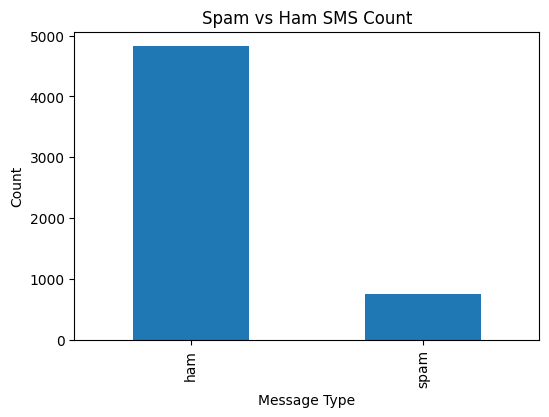


Original Message Example:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Cleaned Message Example:
go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat

Training Size: 4457
Testing Size: 1115

TF-IDF Vectorization completed!
Vector Shape: (4457, 8000)

Training Model: Naive Bayes
Accuracy: 0.9641255605381166
Precision: 0.990990990990991
Recall: 0.738255033557047
F1 Score: 0.8461538461538461

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.74      0.85       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.96      0.96      1115


Training Model: Logistic Regression
Accuracy: 0.9668161434977578
Precision: 0.9912280701754386
Recall: 0.7583892617449665
F1 Score: 0.8593

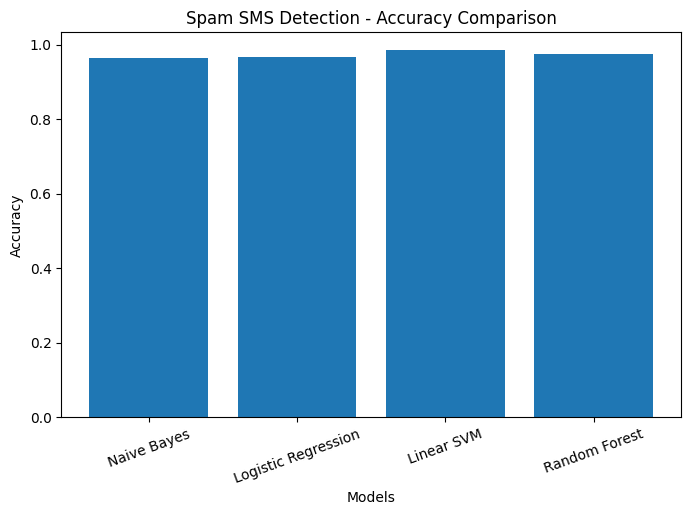

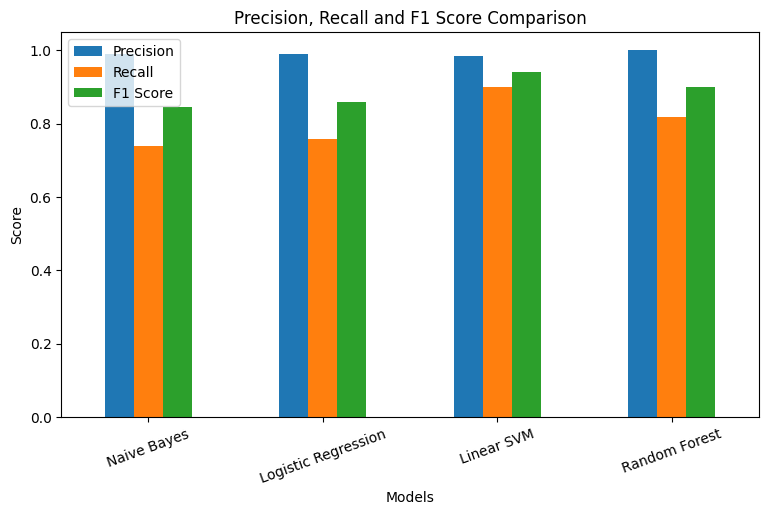

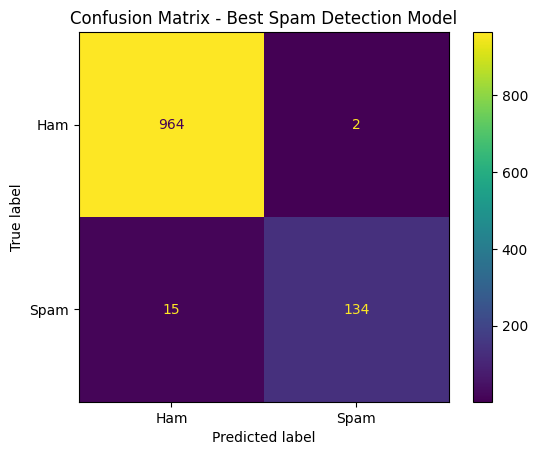

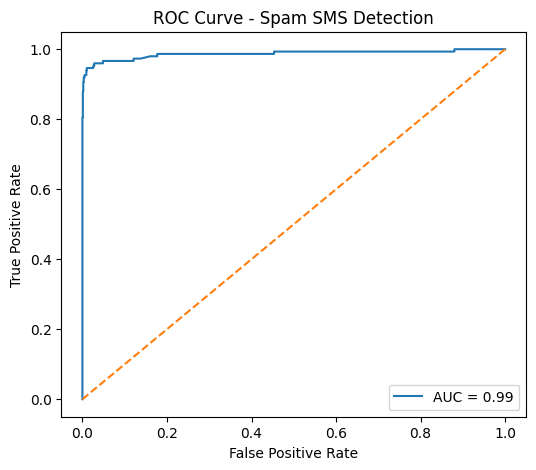

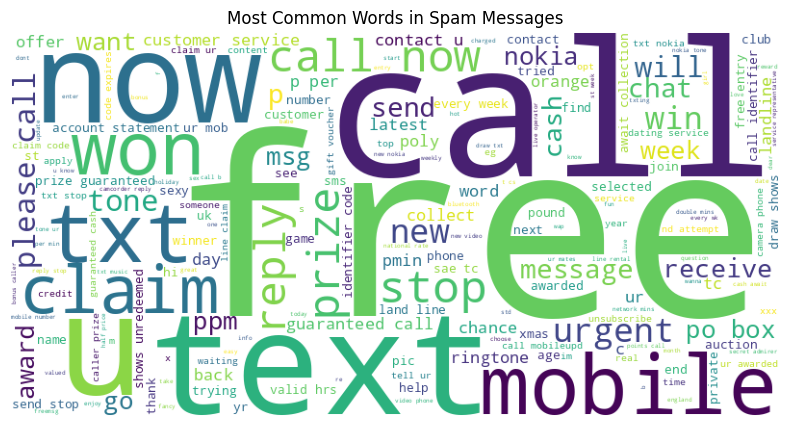

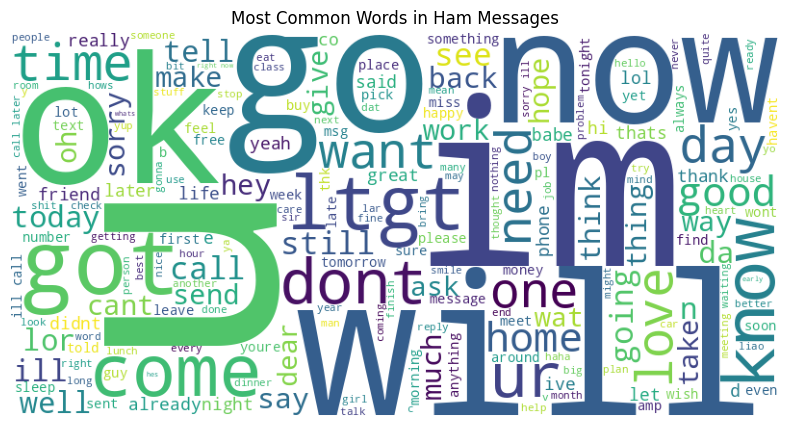


Prediction CSV saved successfully!

========== SAMPLE SMS PREDICTIONS ==========

SMS: Congratulations! You have won a free iPhone. Click the link now.
Prediction: Spam Message

SMS: Hey, are you coming to college tomorrow?
Prediction: Ham Message

SMS: You won 50000 rupees cash prize. Claim immediately.
Prediction: Spam Message

SMS: Your OTP is 4589. Do not share it with anyone.
Prediction: Ham Message

SMS: Free recharge offer available only today. Click here.
Prediction: Ham Message

SMS: Call me when you reach home.
Prediction: Ham Message

SMS: URGENT! Your account has been blocked. Verify now.
Prediction: Spam Message

SMS: Good morning, submit your assignment today.
Prediction: Ham Message

Enter any SMS message to check Spam or Ham: Call me when you reach home.

Your SMS:
Call me when you reach home.

Prediction Result:
Ham Message

Model and vectorizer saved successfully!

========== TASK 2 COMPLETED ==========
Project Name: Spam SMS Detection
Best Model: Linear SVM
Best Acc

In [ ]:

import pandas as pd
import numpy as np
import re
import os
import joblib
import matplotlib.pyplot as plt

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)


print("Uploaded files:")
print(os.listdir())
file_name = "spam.csv"
try:
    sms_data = pd.read_csv(file_name, encoding="latin-1")
except:
    sms_data = pd.read_csv(file_name, sep="\t", names=["Label", "Message"], encoding="latin-1")

print("\nDataset loaded successfully!")
print(sms_data.head())
print("\nOriginal Columns:")
print(sms_data.columns)

if "v1" in sms_data.columns and "v2" in sms_data.columns:
    sms_data = sms_data[["v1", "v2"]]
    sms_data.columns = ["Label", "Message"]

elif len(sms_data.columns) >= 2:
    sms_data = sms_data.iloc[:, :2]
    sms_data.columns = ["Label", "Message"]

print("\nFinal Dataset:")
print(sms_data.head())

print("\nDataset Shape:", sms_data.shape)

print("\nMissing Values:")
print(sms_data.isnull().sum())

sms_data.dropna(inplace=True)

print("\nSpam and Ham Count:")
print(sms_data["Label"].value_counts())

sms_data["Message_Length"] = sms_data["Message"].apply(len)

print("\nAverage Message Length:")
print(sms_data.groupby("Label")["Message_Length"].mean())

plt.figure(figsize=(6, 4))
sms_data["Label"].value_counts().plot(kind="bar")
plt.title("Spam vs Ham SMS Count")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

def clean_message(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

sms_data["Cleaned_Message"] = sms_data["Message"].apply(clean_message)

print("\nOriginal Message Example:")
print(sms_data["Message"].iloc[0])

print("\nCleaned Message Example:")
print(sms_data["Cleaned_Message"].iloc[0])

sms_data["Label"] = sms_data["Label"].astype(str).str.lower()

sms_data["Encoded_Label"] = sms_data["Label"].map({
    "ham": 0,
    "spam": 1
})

sms_data.dropna(subset=["Encoded_Label"], inplace=True)

sms_data["Encoded_Label"] = sms_data["Encoded_Label"].astype(int)
X = sms_data["Cleaned_Message"]
y = sms_data["Encoded_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Size:", X_train.shape[0])
print("Testing Size:", X_test.shape[0])

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=8000,
    ngram_range=(1, 2),
    min_df=1
)

X_train_vector = tfidf_vectorizer.fit_transform(X_train)
X_test_vector = tfidf_vectorizer.transform(X_test)

print("\nTF-IDF Vectorization completed!")
print("Vector Shape:", X_train_vector.shape)

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}
predictions = {}

for model_name, model in models.items():
    print("\n======================================")
    print("Training Model:", model_name)
    print("======================================")

    model.fit(X_train_vector, y_train)

    y_pred = model.predict(X_test_vector)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    predictions[model_name] = y_pred

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

comparison_df = pd.DataFrame(results).T

print("\n========== MODEL COMPARISON ==========")
print(comparison_df)

comparison_df.to_csv("shreenithy_task2_model_comparison.csv")

best_model_name = comparison_df["Accuracy"].idxmax()
best_model = models[best_model_name]
best_prediction = predictions[best_model_name]

print("\nBest Model:", best_model_name)
print("Best Accuracy:", comparison_df.loc[best_model_name, "Accuracy"])
plt.figure(figsize=(8, 5))
plt.bar(comparison_df.index, comparison_df["Accuracy"])
plt.title("Spam SMS Detection - Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()
comparison_df[["Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(9, 5))
plt.title("Precision, Recall and F1 Score Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()

cm = confusion_matrix(y_test, best_prediction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Confusion Matrix - Best Spam Detection Model")
plt.show()

if best_model_name == "Linear SVM":
    score_values = best_model.decision_function(X_test_vector)
else:
    score_values = best_model.predict_proba(X_test_vector)[:, 1]

fpr, tpr, threshold = roc_curve(y_test, score_values)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Spam SMS Detection")
plt.legend()
plt.show()
spam_words = " ".join(sms_data[sms_data["Encoded_Label"] == 1]["Cleaned_Message"])
ham_words = " ".join(sms_data[sms_data["Encoded_Label"] == 0]["Cleaned_Message"])

spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_words)

plt.figure(figsize=(10, 5))
plt.imshow(spam_wordcloud)
plt.axis("off")
plt.title("Most Common Words in Spam Messages")
plt.show()

ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_words)

plt.figure(figsize=(10, 5))
plt.imshow(ham_wordcloud)
plt.axis("off")
plt.title("Most Common Words in Ham Messages")
plt.show()

prediction_df = pd.DataFrame({
    "Actual_Label": y_test.values,
    "Predicted_Label": best_prediction
})

prediction_df["Actual_Label"] = prediction_df["Actual_Label"].map({
    0: "Ham",
    1: "Spam"
})

prediction_df["Predicted_Label"] = prediction_df["Predicted_Label"].map({
    0: "Ham",
    1: "Spam"
})

prediction_df.to_csv("shreenithy_task2_predictions.csv", index=False)

print("\nPrediction CSV saved successfully!")

def shreenithy_spam_detector(message):
    cleaned = clean_message(message)
    vectorized = tfidf_vectorizer.transform([cleaned])
    prediction = best_model.predict(vectorized)[0]

    if prediction == 1:
        return "Spam Message"
    else:
        return "Ham Message"
sample_sms_list = [
    "Congratulations! You have won a free iPhone. Click the link now.",
    "Hey, are you coming to college tomorrow?",
    "You won 50000 rupees cash prize. Claim immediately.",
    "Your OTP is 4589. Do not share it with anyone.",
    "Free recharge offer available only today. Click here.",
    "Call me when you reach home.",
    "URGENT! Your account has been blocked. Verify now.",
    "Good morning, submit your assignment today."
]

print("\n========== SAMPLE SMS PREDICTIONS ==========")

for sms in sample_sms_list:
    print("\nSMS:", sms)
    print("Prediction:", shreenithy_spam_detector(sms))
user_sms = input("\nEnter any SMS message to check Spam or Ham: ")

print("\nYour SMS:")
print(user_sms)

print("\nPrediction Result:")
print(shreenithy_spam_detector(user_sms))
joblib.dump(best_model, "shreenithy_spam_sms_model.pkl")
joblib.dump(tfidf_vectorizer, "shreenithy_spam_tfidf_vectorizer.pkl")

print("\nModel and vectorizer saved successfully!")

print("\n========== TASK 2 COMPLETED ==========")
print("Project Name: Spam SMS Detection")
print("Best Model:", best_model_name)
print("Best Accuracy:", comparison_df.loc[best_model_name, "Accuracy"])

print("\nModels Used:")
for model in models.keys():
    print("-", model)

print("\nTask 2 completed successfully!")